
## DCGAN on MNIST Handwritten Digits

This project implements a **Deep Convolutional Generative Adversarial Network (DCGAN)** using TensorFlow and Keras to generate synthetic handwritten digit images based on the MNIST dataset.

The goal of this project is to train a generator network to create realistic digit images from random noise, while a discriminator network learns to distinguish between real MNIST images and fake generated images. Through this adversarial process, both networks improve over time.

The model is trained on grayscale handwritten digit images of size **28 × 28**, and the outputs are saved at regular intervals to monitor how image quality improves across epochs.

## Importing Required Libraries

This section imports all the libraries needed for the GAN project.

- **os** is used for creating folders and saving output files.
- **numpy** is used for numerical operations and array handling.
- **matplotlib.pyplot** is used to visualize and save generated images and training loss graphs.
- **tensorflow** provides the deep learning framework used to build and train the GAN.
- **layers** and **Sequential** from Keras are used to define the generator and discriminator models.
- **mnist** is used to load the MNIST handwritten digit dataset directly from Keras.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.datasets import mnist


## Setting Hyperparameters

This section defines the main hyperparameters used throughout the training process.

- **LATENT_DIM = 100**  
  This is the size of the random noise vector given to the generator. The generator transforms this noise into a synthetic image.

- **BATCH_SIZE = 128**  
  This specifies how many images are processed in one batch during training.

- **EPOCHS = 50**  
  This is the total number of times the full training dataset is passed through the model.

- **SAVE_INTERVAL = 5**  
  Generated sample images are saved every 5 epochs so that training progress can be visually monitored.

- **LEARNING_RATE = 0.0002**  
  This controls how quickly the model updates its weights during training.

- **BETA_1 = 0.5**  
  This is a momentum-related parameter for the Adam optimizer. In GANs, setting beta_1 to 0.5 is a common practice to improve training stability.

- **OUTPUT_DIR = "gan_outputs"**  
  This is the folder where generated images, plots, and trained models are saved.

The output directory is created automatically if it does not already exist.

In [2]:
LATENT_DIM = 100
BATCH_SIZE = 128
EPOCHS = 50
SAVE_INTERVAL = 5
LEARNING_RATE = 0.0002
BETA_1 = 0.5
OUTPUT_DIR = "gan_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)


## Loading and Preprocessing the MNIST Dataset

In this section, the MNIST handwritten digit dataset is loaded and prepared for training.

### Step 1: Load the dataset
The MNIST dataset contains **60,000 training images** of handwritten digits from 0 to 9. In this project, only the training images are used because GANs learn by modeling the data distribution rather than using labels.

### Step 2: Normalize pixel values
The original pixel values range from **0 to 255**. These values are scaled to the range **[-1, 1]** using the formula:

\[
x = \frac{x - 127.5}{127.5}
\]

This normalization is important because the generator uses a **tanh** activation function in the output layer, which also produces values in the range [-1, 1].

### Step 3: Add channel dimension
MNIST images are originally of shape **(28, 28)**. Since convolutional neural networks expect image data with a channel dimension, the data is reshaped to **(28, 28, 1)**, where 1 represents a grayscale channel.

### Step 4: Create TensorFlow dataset
The training images are converted into a TensorFlow dataset, shuffled randomly, and grouped into batches.  
- Shuffling ensures the model sees images in a different order each epoch.
- Batching improves training efficiency.
- `drop_remainder=True` ensures that all batches have exactly the same size, which is necessary because the training step expects a fixed batch size.

In [3]:

# LOAD AND PREPROCESS DATA

(x_train, _), (_, _) = mnist.load_data()

# Normalize to [-1, 1]
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)  # shape: (60000, 28, 28, 1)

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(buffer_size=60000).batch(BATCH_SIZE, drop_remainder=True)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


## Building the Generator

The generator is the part of the GAN responsible for creating fake handwritten digit images from random noise.

It starts with a random vector of size **100** and gradually transforms it into a **28 × 28 × 1** image using dense and transposed convolutional layers.

### Layer-by-layer explanation

1. **Dense layer**
   - The input noise vector is passed through a fully connected layer.
   - The output size is `7 × 7 × 256`, which provides a rich set of learned features.

2. **Batch Normalization**
   - This helps stabilize training by normalizing activations.
   - It also improves gradient flow and makes GAN training more reliable.

3. **LeakyReLU activation**
   - This introduces non-linearity and helps avoid dead neurons.

4. **Reshape**
   - The flat vector is reshaped into a feature map of shape **(7, 7, 256)**.

5. **Conv2DTranspose layer**
   - This is also called a deconvolution or upsampling layer.
   - It increases or refines the spatial dimensions of the feature maps.

6. **Final output layer**
   - The last transposed convolution converts the feature maps into a **single-channel grayscale image**.
   - The **tanh** activation is used so the output matches the normalized image range of **[-1, 1]**.

Overall, the generator learns how to convert random noise into images that resemble real MNIST digits.

In [4]:
# BUILD GENERATOR

def build_generator():
    model = Sequential(name="Generator")

    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(LATENT_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))  # (7, 7, 256)

    model.add(layers.Conv2DTranspose(128, kernel_size=5, strides=1, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())  # (7, 7, 128)

    model.add(layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())  # (14, 14, 64)

    model.add(layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding="same", use_bias=False, activation="tanh"))
    # Output: (28, 28, 1)

    return model

## Building the Discriminator

The discriminator is the part of the GAN that decides whether an image is **real** (from the MNIST dataset) or **fake** (generated by the generator).

It acts like a binary classifier and outputs a probability indicating how likely the input image is to be real.

### Layer-by-layer explanation

1. **First convolution layer**
   - Extracts low-level image features such as edges and basic patterns.
   - Uses stride 2 to reduce the image size while learning useful features.

2. **LeakyReLU activation**
   - Adds non-linearity and helps the model learn more complex patterns.

3. **Dropout**
   - Randomly disables some neurons during training.
   - This reduces overfitting and makes the discriminator less likely to become too dominant.

4. **Second convolution layer**
   - Learns more advanced image features from the reduced feature maps.

5. **Flatten**
   - Converts the 2D feature maps into a 1D vector so that it can be passed into a dense layer.

6. **Dense output layer**
   - Produces a single value between 0 and 1 using a **sigmoid** activation.
   - Values close to 1 indicate the image is likely real.
   - Values close to 0 indicate the image is likely fake.

The discriminator’s job is to become better at spotting fake images, while the generator tries to fool it.

In [5]:
# BUILD DISCRIMINATOR

def build_discriminator():
    model = Sequential(name="Discriminator")

    model.add(layers.Conv2D(64, kernel_size=5, strides=2, padding="same", input_shape=(28, 28, 1)))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, kernel_size=5, strides=2, padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))

    return model

generator = build_generator()
discriminator = build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Defining the Loss Functions

GAN training requires separate loss functions for the generator and the discriminator.

This project uses **Binary Cross-Entropy Loss**, which is suitable because the discriminator performs a binary classification task: real or fake.

### Generator Loss
The generator wants the discriminator to classify fake images as real.  
So, when fake images are passed to the discriminator, the generator compares the output against a target of **1s**.

This means:
- If the discriminator believes the fake images are real, the generator loss becomes smaller.
- If the discriminator easily detects they are fake, the generator loss becomes larger.

### Discriminator Loss
The discriminator has two tasks:
1. Classify real images as real
2. Classify fake images as fake

So its total loss is the sum of:
- **real loss**: compares real image predictions with 1s
- **fake loss**: compares fake image predictions with 0s

This creates the adversarial training setup:
- The **generator** tries to minimize its loss by fooling the discriminator.
- The **discriminator** tries to minimize its loss by correctly detecting real and fake images.

In [6]:
# LOSS FUNCTIONS

cross_entropy = tf.keras.losses.BinaryCrossentropy()

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

## Configuring the Optimizers

Both the generator and discriminator use the **Adam optimizer**.

Adam is a popular optimization algorithm because it adapts the learning rate during training and usually converges faster than standard gradient descent.

The same optimizer settings are used for both networks:
- **Learning rate = 0.0002**
- **beta_1 = 0.5**

These values are commonly used in GAN training because they help improve stability and reduce oscillations during the adversarial learning process.

In [7]:
#OPTIMIZERS

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)


## Defining One Training Step

This section defines a single training step for the GAN using TensorFlow’s `@tf.function` decorator.

The decorator converts the Python function into a TensorFlow graph, which improves performance during training.

### What happens in one training step?

1. **Generate random noise**
   - A batch of random vectors is created.
   - These vectors are used as input to the generator.

2. **Generate fake images**
   - The generator converts the noise into fake digit images.

3. **Get discriminator predictions**
   - The discriminator evaluates both:
     - real MNIST images
     - fake generated images

4. **Calculate losses**
   - Generator loss measures how well the generator fooled the discriminator.
   - Discriminator loss measures how well the discriminator separated real and fake images.

5. **Compute gradients**
   - TensorFlow’s `GradientTape` records operations and computes gradients for both models.

6. **Update model weights**
   - The generator optimizer updates generator parameters.
   - The discriminator optimizer updates discriminator parameters.

This function is the core of the GAN training process because it allows both networks to learn at the same time in opposite directions.

In [8]:
# TRAIN STEP

@tf.function
def train_step(real_images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(g_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return g_loss, d_loss

## Saving Generated Images During Training

This function generates and saves sample images at different training stages.

A fixed random seed is used so that the same latent vectors are passed to the generator each time. This makes it easier to compare image quality across epochs because changes in the output are due to learning, not random input differences.

### Process
1. Generate fake images using the current generator.
2. Convert image values from **[-1, 1]** back to **[0, 1]** for display.
3. Plot the generated digits in a **4 × 4 grid**.
4. Save the image to the output folder.

This helps visually track whether the generator is improving over time.

In [9]:
# SAVE GENERATED IMAGES

def save_generated_images(epoch, seed):
    predictions = generator(seed, training=False)
    predictions = (predictions + 1.0) / 2.0  # back to [0, 1]

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"generated_epoch_{epoch:03d}.png"))
    plt.close()

## Training the GAN

This section contains the full training loop that runs for the specified number of epochs.

### What happens during each epoch?

1. Initialize variables to store the total generator and discriminator loss.
2. Loop through all image batches in the dataset.
3. Call `train_step()` on each batch.
4. Accumulate batch losses.
5. Compute the average generator and discriminator loss for the epoch.
6. Store these values so they can later be plotted.
7. Print the losses so training progress can be monitored in the console.
8. Save generated sample images at regular intervals.

### Why average the losses?
Each epoch contains many batches. Averaging the loss across all batches gives a more stable and meaningful summary of training progress.

### Why save sample outputs?
GAN losses alone do not always clearly show image quality. Visual inspection of generated samples is very important in GAN projects because the generator may appear to improve visually even when the numerical losses fluctuate.

In [10]:
# TRAINING LOOP

def train(dataset, epochs):
    gen_losses = []
    disc_losses = []

    fixed_seed = tf.random.normal([16, LATENT_DIM])

    for epoch in range(1, epochs + 1):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        batch_count = 0

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            epoch_g_loss += g_loss.numpy()
            epoch_d_loss += d_loss.numpy()
            batch_count += 1

        avg_g_loss = epoch_g_loss / batch_count
        avg_d_loss = epoch_d_loss / batch_count

        gen_losses.append(avg_g_loss)
        disc_losses.append(avg_d_loss)

        print(f"Epoch {epoch}/{epochs} | Generator Loss: {avg_g_loss:.4f} | Discriminator Loss: {avg_d_loss:.4f}")

        if epoch % SAVE_INTERVAL == 0 or epoch == 1:
            save_generated_images(epoch, fixed_seed)

    return gen_losses, disc_losses

## Plotting Training Loss

After training, the generator and discriminator losses are plotted across epochs.

This plot helps analyze the learning behaviour of both networks:
- If one model becomes too strong too quickly, training may become unstable.
- In GANs, some fluctuation in loss is normal because the two models are competing against each other.
- The goal is not always perfectly decreasing loss, but rather balanced adversarial learning.

The loss graph is saved to the output directory and also displayed on screen.

In [11]:
# PLOT LOSSES

def plot_losses(gen_losses, disc_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(gen_losses, label="Generator Loss")
    plt.plot(disc_losses, label="Discriminator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN Training Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "training_loss.png"))
    plt.show()

## Saving the Trained Models

Once training is complete, both the generator and discriminator are saved as `.h5` model files.

### Why save the models?
Saving the trained models allows them to be reused later for:
- generating new handwritten digits without retraining
- further fine-tuning
- evaluation or demonstration
- deployment in future applications

The generator is especially important because it is the model used to create new synthetic digit images.

In [14]:
# SAVE FINAL MODELS

def save_models():
    generator.save(os.path.join(OUTPUT_DIR, "generator_model.keras"), include_optimizer=False)
    discriminator.save(os.path.join(OUTPUT_DIR, "discriminator_model.keras"), include_optimizer=False)
    print("Models saved successfully.")

## Main Execution Block

This is the entry point of the project.

When the script is executed directly:

1. Training begins.
2. The model trains for the specified number of epochs.
3. Generator and discriminator losses are stored.
4. A training loss graph is plotted and saved.
5. Both trained models are saved.
6. A final message confirms that all outputs have been written to the output folder.

This structure keeps the workflow organized and makes the script easier to run as a standalone program.

Starting GAN training...
Epoch 1/50 | Generator Loss: 0.8056 | Discriminator Loss: 1.3163
Epoch 2/50 | Generator Loss: 0.8043 | Discriminator Loss: 1.3142
Epoch 3/50 | Generator Loss: 0.8176 | Discriminator Loss: 1.3093
Epoch 4/50 | Generator Loss: 0.8009 | Discriminator Loss: 1.3149
Epoch 5/50 | Generator Loss: 0.8073 | Discriminator Loss: 1.3143
Epoch 6/50 | Generator Loss: 0.8004 | Discriminator Loss: 1.3183
Epoch 7/50 | Generator Loss: 0.8091 | Discriminator Loss: 1.3115
Epoch 8/50 | Generator Loss: 0.8096 | Discriminator Loss: 1.3131
Epoch 9/50 | Generator Loss: 0.8088 | Discriminator Loss: 1.3130
Epoch 10/50 | Generator Loss: 0.8036 | Discriminator Loss: 1.3163
Epoch 11/50 | Generator Loss: 0.8119 | Discriminator Loss: 1.3125
Epoch 12/50 | Generator Loss: 0.8044 | Discriminator Loss: 1.3152
Epoch 13/50 | Generator Loss: 0.8144 | Discriminator Loss: 1.3121
Epoch 14/50 | Generator Loss: 0.8043 | Discriminator Loss: 1.3138
Epoch 15/50 | Generator Loss: 0.8064 | Discriminator Loss: 1

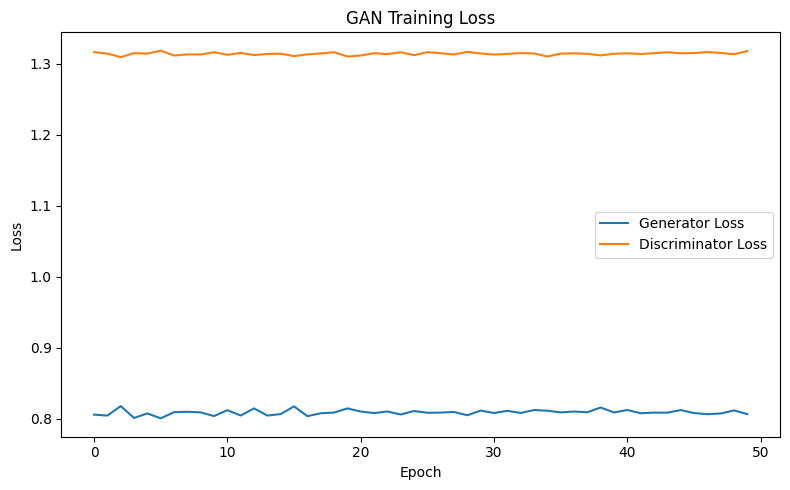

Models saved successfully.
Done. Outputs saved in folder: gan_outputs


In [15]:
# MAIN
if __name__ == "__main__":
    print("Starting GAN training...")
    gen_losses, disc_losses = train(dataset, EPOCHS)
    plot_losses(gen_losses, disc_losses)
    save_models()
    print(f"Done. Outputs saved in folder: {OUTPUT_DIR}")